In [2]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [10]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, PerturbedPrimalDualOpt, DualDecompOpt, VQECResult
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer.primitives import Estimator
from qiskit_algorithms.gradients import LinCombEstimatorGradient, ParamShiftEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
import json
import os

In [14]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = None

    penalty_terms = PenaltyParameters(
        penalty_back=penalty_back,
        penalty_redun=penalty_redun,
        penalty_olap=penalty_olap,
    )

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

## Single run workflow

In [20]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
Number of qubits: 24
Number of terms: 2199


In [21]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 6
Number of qubits: 24


In [7]:
ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

init_dual_vars = np.array([0.0] * len(olap_constr_ops))
vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
    primal_perturb_step=0.05,
    dual_perturb_step=0.05,
)

vqec_result = vqec.optimize_primal_dual(initial_dual_vars=init_dual_vars, max_iter=300)
print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)
print(f"Optimal energy: {vqec_result.energies[-1]}")

 69%|██████▉   | 208/300 [16:43<07:23,  4.82s/it]

Converged after 209 iterations
[3.14159265e+00 6.28318531e+00 3.14159265e+00 3.14159265e+00
 3.14159265e+00 3.14159265e+00 3.14159265e+00 3.02939893e-02
 4.35228562e-13 0.00000000e+00 6.28318531e+00 3.14159265e+00
 6.28318531e+00 3.14159265e+00 3.14159265e+00 1.88847042e-15
 3.14159265e+00 3.14159265e+00 6.28318531e+00 3.03076369e-08
 4.29972154e-06 6.27710400e+00 2.01587994e+00 3.09522269e+00]
[5.93854033e-17 0.00000000e+00 0.00000000e+00 6.13771968e-02
 8.03405624e+00 1.13828161e-17]
Optimal energy: -42.340775989706444


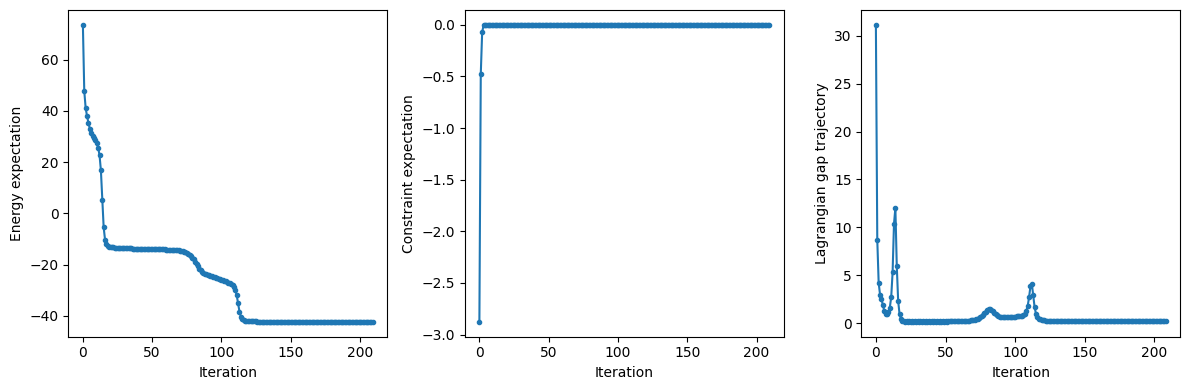

In [8]:
# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")

plt.tight_layout()
plt.show()

In [9]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

/var/folders/f0/3f43g55s7jj8xnhyp1dq2nfh0000gn/T/ipykernel_5287/2213236805.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Sample 0: 101111101101100000101011 with probability 0.7141 and energy -42.56999999999998
Sample 1: 011111101101100000101011 with probability 0.2851 and energy -41.79999999999998
Sample 2: 001111101101100000101011 with probability 0.0005 and energy -37.75999999999998
Sample 3: 010000010010011110101011 with probability 0.0003 and energy -7.399999999999999


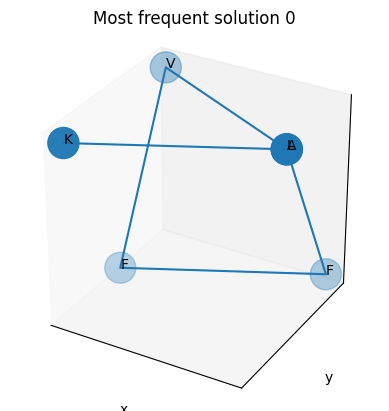

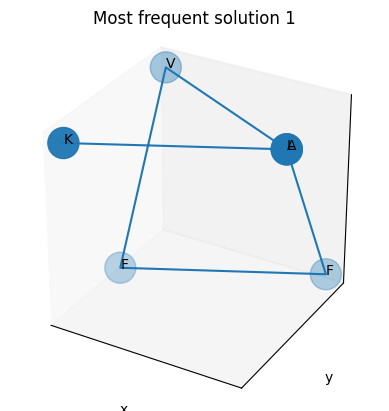

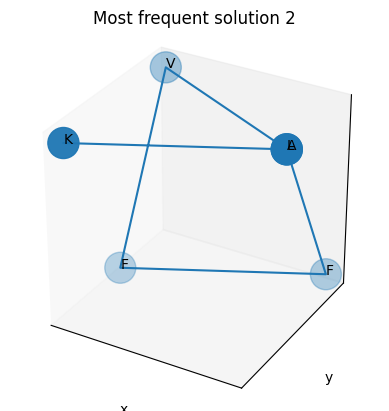

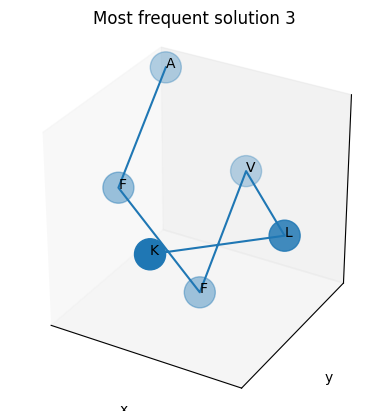

In [10]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

## Parallelized runs workflow

In [22]:
import ray

In [23]:
@ray.remote
def _optimize_ray(
    ppd_opt: PerturbedPrimalDualOpt,
    init_params: np.ndarray | None = None,
    init_dual_vars: np.ndarray | None = None,
    primal_perturb_step: float = 0.05,
    dual_perturb_step: float = 0.05,
    primal_dual_update_step: float = 1,
    max_iter: int = 300,
) -> VQECResult:
    """Optimize the given problem using the Perturbed Primal Dual method."""
    return ppd_opt.optimize_primal_dual(
        initial_params=init_params,
        initial_dual_vars=init_dual_vars,
        primal_perturb_step=primal_perturb_step,
        dual_perturb_step=dual_perturb_step,
        gamma=primal_dual_update_step,
        max_iter=max_iter,
    )

In [27]:
ray.shutdown()

In [24]:
import psutil
import vqe

num_cpus = psutil.cpu_count(logical=False)
print(f"Number of CPUs: {num_cpus}")
ray.init(
    ignore_reinit_error=True,
    num_cpus=num_cpus,
    runtime_env={
        "py_modules": [vqe],
    },
)

Number of CPUs: 12


2025-05-02 16:31:30,233	INFO worker.py:1772 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2025-05-02 16:31:30,251	INFO packaging.py:530 -- Creating a file package for local directory '/Users/lir9/protein-folding-qc/notebooks/../vqe'.
2025-05-02 16:31:30,264	INFO packaging.py:358 -- Pushing file package 'gcs://_ray_pkg_bd531a8483bea683.zip' (0.07MiB) to Ray cluster...
2025-05-02 16:31:30,265	INFO packaging.py:371 -- Successfully pushed file package 'gcs://_ray_pkg_bd531a8483bea683.zip'.


Python version:,3.12.2
Ray version:,2.34.0
Dashboard:,http://127.0.0.1:8265


100%|██████████| 5/5 [00:25<00:00,  5.08s/it]


In [26]:
# num_opt_runs = 4
max_iter = 5
update_steps = [0.1, 0.5, 1.0, 2.0]

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=1,
    entanglement="linear",
    skip_final_rotation_layer=True,
)
estimator = Estimator(
    backend_options={"method": "matrix_product_state"},
    run_options={"shots": None},
    approximation=True,
)
# estimator = Estimator()
gradient = ParamShiftEstimatorGradient(estimator=estimator)

vqec = PerturbedPrimalDualOpt(
    qubit_op=qubit_op,
    constr_ops=olap_constr_ops,
    ansatz=ansatz,
    estimator=estimator,
    gradient=gradient,
)
res = ray.get(
    [
        _optimize_ray.remote(
            ppd_opt=vqec,
            init_params=None,
            init_dual_vars=None,
            primal_perturb_step=0.05,
            dual_perturb_step=0.05,
            primal_dual_update_step=update_step,
            max_iter=max_iter,
        )
        for update_step in update_steps
    ]
)

In [27]:
for i, r in enumerate(res):
    r.write_to_json(f"vqec_run_{i}.json")

## HPC data postprocessing

In [28]:
from fcc.fcc_protein_shape import ProteinShapeDecoder, ProteinShapeFileGen

In [29]:
def check_overlaps(peptide: Peptide, bitstring: str) -> None | list[tuple[int, int]]:
    """Check the overlaps of the given bitstring."""
    # Convert the bitstring to the set of turns 
    psd = ProteinShapeDecoder(peptide=peptide, solution_bitstring=bitstring)
    turn_seq = psd.turn_sequence
    psfg = ProteinShapeFileGen(peptide=peptide, turn_sequence=turn_seq)
    # Get the coordinates of the beads
    coords = psfg.generate_amino_acid_positions()
    # Check for overlaps
    overlaps = []
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            if np.isclose(np.linalg.norm(coords[i] - coords[j]), 0.0):
                overlaps.append((i, j))
    if len(overlaps) > 0:
        return overlaps
    # If no overlaps, return None
    return None


def sample_optimized_circ(ansatz: QuantumCircuit, optimized_params: np.ndarray, shots: int) -> dict[str, float]:
    """Sample the optimized circuit and return the quasi distribution."""
    # Create a copy of the ansatz
    full_circ = ansatz.copy()
    # Measure all qubits
    full_circ.measure_all()
    # Create a sampler
    sampler = Sampler(options={"shots": shots})
    # Run the sampler
    sampler_result = sampler.run(circuits=[full_circ], parameter_values=optimized_params).result()
    # Get the quasi distribution
    quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
    # Sort the binary strings by their probabilities
    sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
    return sorted_quasi_dist

In [30]:
main_seq = "KLVFFA" # 6MVZ ("LFLF")YYDPETGTWY
peptide = Peptide(main_seq)
bitstring_test = "101111101101100000101011"
check_overlaps(peptide, bitstring_test)

[(1, 5)]

In [38]:
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

ansatz = TwoLocal(
    qubit_op.num_qubits,
    ["ry"],
    "cx",
    reps=2,
    entanglement="linear",
    skip_final_rotation_layer=True,
)

dir = "vqec_results/"
# Loop through the files in the directory
for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            update_step = data["primal_dual_update_step"]
            print(f"VQEC run with variable update step size = {update_step}")
            # Get the optimized variational parameters
            optimal_primal_vars = data["optimal_primal_vars"]
            sorted_quasi_dist = sample_optimized_circ(ansatz, optimal_primal_vars, shots=10000)
            # Compute the energies of all samples
            bitstring_energies = {}
            for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
                if i >= 5:
                    break
                energy = _evaluate_sparsepauli(sample, qubit_op)
                # Check for overlaps
                overlaps = check_overlaps(peptide, sample)
                bitstring_energies[sample] = (energy, prob, overlaps)
                print(f"Sample {i}: {sample} with probability {prob}, energy {energy}, and overlaps {overlaps}")

[[ 0.   -3.37 -2.49 -3.36 -3.36 -1.31]
 [ 0.    0.   -6.48 -7.28 -7.28 -4.91]
 [ 0.    0.    0.   -6.29 -6.29 -4.04]
 [ 0.    0.    0.    0.   -7.26 -4.81]
 [ 0.    0.    0.    0.    0.   -4.81]
 [ 0.    0.    0.    0.    0.    0.  ]]
VQEC run with variable update step size = 0.2


/var/folders/6z/68dj05v5057cwh6yv32zx6380000gp/T/ipykernel_29867/1207470909.py:28: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": shots})


Sample 0: 101000000000011111100111 with probability 0.0102, energy 0.8139999999999827, and overlaps None
Sample 1: 010111111110100000011011 with probability 0.01, energy -2.5430000000000015, and overlaps [(1, 5)]
Sample 2: 010111111111100000011011 with probability 0.0097, energy 1.9969999999999986, and overlaps None
Sample 3: 101000000001011101100111 with probability 0.0096, energy 0.8139999999999916, and overlaps None
Sample 4: 101000000001011111100111 with probability 0.0093, energy -1.1100000000000172, and overlaps None
VQEC run with variable update step size = 0.4
Sample 0: 101000110011010001111010 with probability 0.0129, energy 0.64299999999998, and overlaps [(1, 5)]
Sample 1: 010111001111010001111010 with probability 0.0122, energy -2.4620000000000193, and overlaps [(1, 5)]
Sample 2: 010111001001010001111010 with probability 0.0092, energy -1.2310000000000163, and overlaps None
Sample 3: 101000110101010001111010 with probability 0.0085, energy -0.3060000000000189, and overlaps N

VQEC run with variable update step size = 0.2


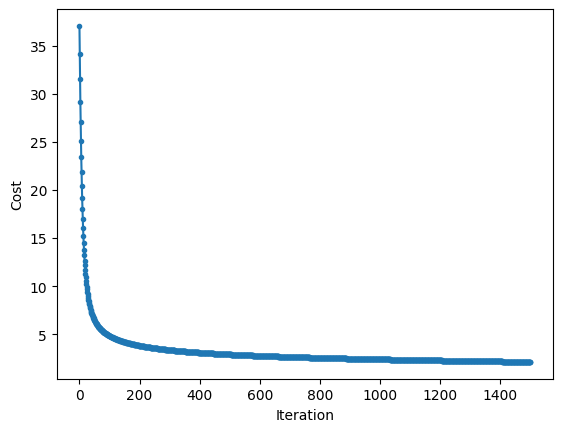

VQEC run with variable update step size = 0.4


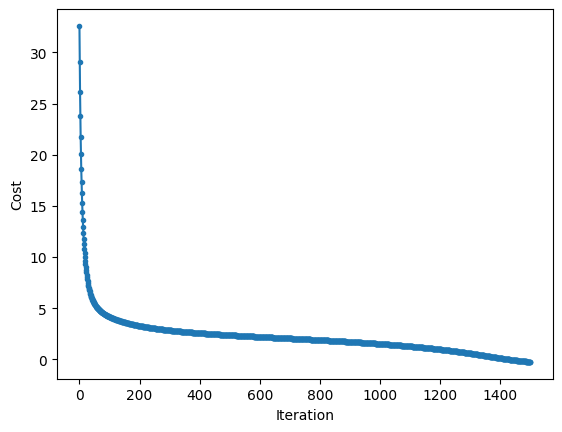

VQEC run with variable update step size = 0.6


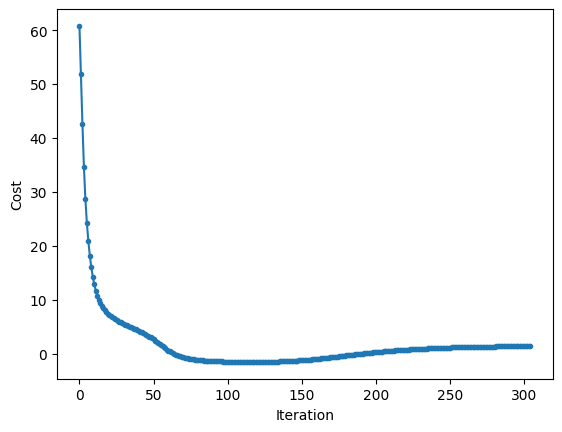

VQEC run with variable update step size = 0.8


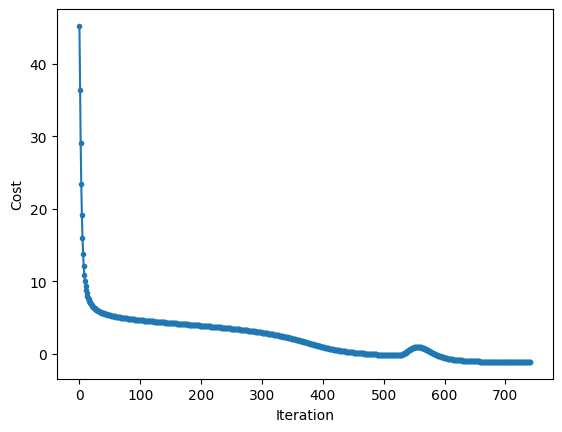

VQEC run with variable update step size = 1.0


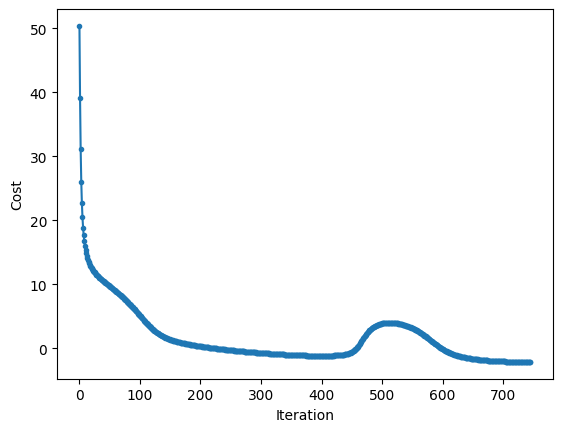

VQEC run with variable update step size = 1.5


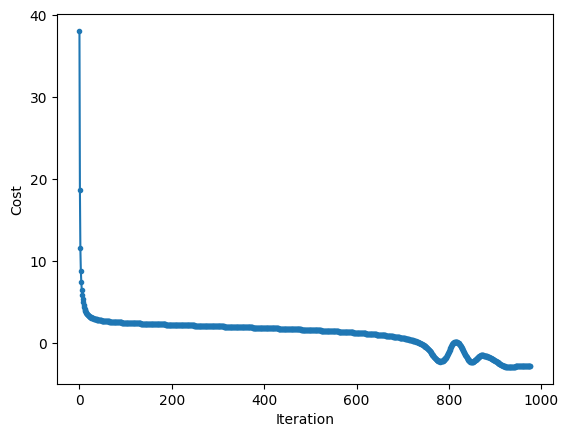

VQEC run with variable update step size = 2.0


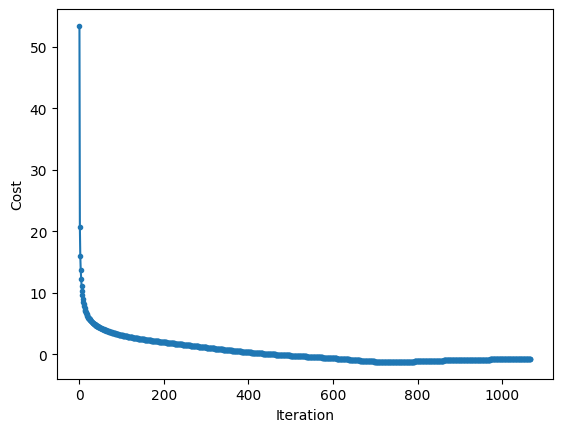

VQEC run with variable update step size = 2.5


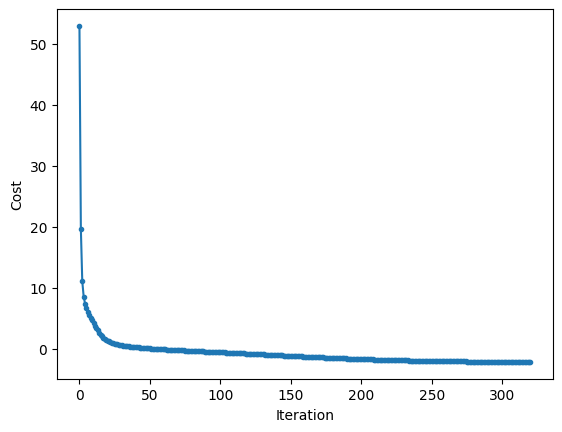

VQEC run with variable update step size = 3.0


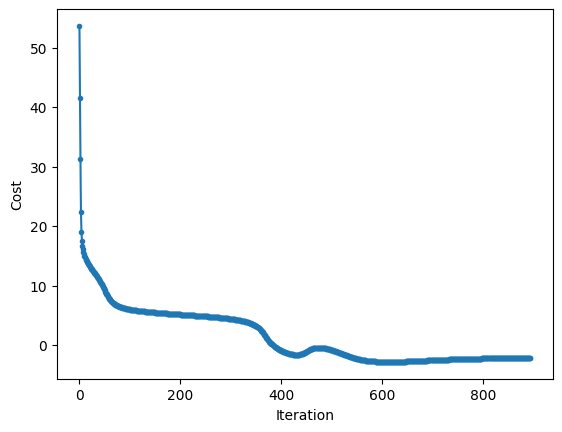

VQEC run with variable update step size = 3.5


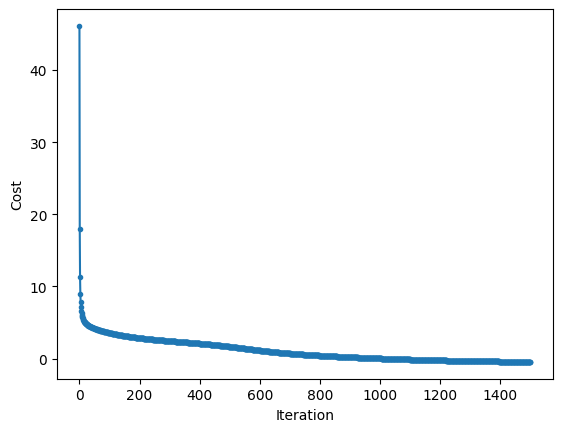

VQEC run with variable update step size = 4.0


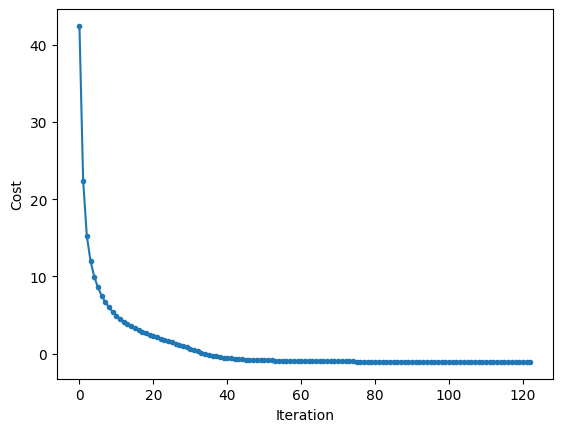

In [39]:
for filename in sorted(os.listdir(dir)):
    # Check if the file is a JSON file
    if filename.endswith(".json"):
        # Open the JSON file
        with open(os.path.join(dir, filename), "r") as f:
            # Load the JSON data
            data = json.load(f)
            update_step = data["primal_dual_update_step"]
            print(f"VQEC run with variable update step size = {update_step}")
            cost_trajectory = data["energies"]
            # Plot the cost trajectory
            plt.plot(cost_trajectory, label=f"VQEC run {i}", marker=".")
            plt.xlabel("Iteration")
            plt.ylabel("Cost")
            plt.show()

## Miscellaneous

In [11]:
ansatz = TwoLocal(qubit_op.num_qubits, ['ry'], 'cx', reps=1, entanglement='linear', skip_final_rotation_layer=True)
init_params = [np.random.rand(ansatz.num_parameters)]
# estimator = Estimator(backend_options={'method': 'statevector'})
estimator = Estimator(backend_options={'method': 'matrix_product_state'}, run_options={'shots': None}, approximation=True)
gradient_1 = LinCombEstimatorGradient(estimator=estimator)
gradient_2 = ParamShiftEstimatorGradient(estimator=estimator)
gradient_3 = FiniteDiffEstimatorGradient(estimator=estimator, epsilon=0.001)

In [16]:
grad_result_1 = gradient_1.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_1.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.15424398])]

In [14]:
grad_result_2 = gradient_2.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_2.result().gradients

[array([-24.6522316 ,  -8.3543522 , -15.33924042, -17.66810352,
        -24.91474543,  -5.3918116 ,  -7.38997048,  -0.99347861,
        -21.46319724, -18.40985139,   8.06716479,  -2.99647204,
         -0.88005039,  17.75540077,   1.55650454,  25.54264364,
         12.80644996,   4.51805965,  11.71222944,   4.05098697,
          6.9476704 ,   0.59124748,   0.2470542 ,   0.154244  ])]

In [13]:
grad_result_3 = gradient_3.run(circuits=ansatz, observables=qubit_op, parameter_values=init_params)
grad_result_3.result().gradients

[array([-24.6522275 ,  -8.3543508 , -15.33923786, -17.66810057,
        -24.91474127,  -5.39181071,  -7.38996925,  -0.99347845,
        -21.46319366, -18.40984832,   8.06716344,  -2.99647154,
         -0.88005024,  17.75539781,   1.55650428,  25.54263939,
         12.80644782,   4.5180589 ,  11.71222749,   4.05098629,
          6.94766924,   0.59124738,   0.24705416,   0.15424398])]